Набор данных содержит сведения о должностях, показатели оплаты труда, данные о профессиональном опыте, условиях и форматах работы, особенностях карьеры, характеристиках, связанных с ИИ, а также аналитическую информацию о занятости.

На основании этих данных нам предлагается проверить несколько гипотез:
1) Уровень оплаты зависит от страны, в которой находится компания;
2) Более высокий требуемый уровень образования связан с более высокой заработной платой;
3) Python является наиболее востребованным языком программирования среди AI-вакансий;
4) Чем выше требуемый опыт, тем ниже риск автоматизации;

**Ход исследования**

Набор данных о вакансиях в сфере ИИ содержится в файле "global_ai_jobs_2026.csv". Необходимо проверить данные на ошибки, оценить их влияние на исследование. Затем, на этапе предобработки следует попытаться исправить самые критичные ошибки в данных.


**Примерный план исследования:**
1) Обзор данных
2) Предобработка данных
3) Проверка гипотез
4) Выводы исследования

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

jobs = pd.read_csv('global_ai_jobs_2026.csv', sep=',')

unique_skills = (
    jobs['Skills_Required']
    .dropna()              # Исключаем пустые значения
    .str.split(',')        # Разбиваем строку в список: "Python, SQL" -> ["Python", " SQL"]
    .explode()             # Разворачиваем списки в один длинный столбец
    .str.strip()           # Удаляем пробелы по краям (чтобы "SQL" и " SQL" не стали разными)
    .unique()              # Оставляем только уникальные значения
)

jobs['Education_Required'].unique()

array(["Bachelor's", "Master's", 'Postdoctoral', 'PhD'], dtype=object)

Таблица содержит достаточное большое количество характеристик. Посмотрим полный список характеристик и общую информацию датасэта:

In [ ]:
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Job_ID                          5000 non-null   object 
 1   Job_Title                       5000 non-null   object 
 2   AI_Specialization               5000 non-null   object 
 3   Industry                        5000 non-null   object 
 4   Company                         5000 non-null   object 
 5   Company_Size                    5000 non-null   object 
 6   Country                         5000 non-null   object 
 7   Continent                       5000 non-null   object 
 8   Education_Required              5000 non-null   object 
 9   Experience_Level                5000 non-null   object 
 10  Years_of_Experience             5000 non-null   int64  
 11  Salary_USD                      5000 non-null   float64
 12  Salary_Min                      50

Из полученных данных видно, что в таблице 37 столбцов, 5000 строк. Встречаются следующие типы данных: float64, int64, object.

Столбца проименованы корректно, каждое отдельное слово начинается с заглавной буквы, слова разделены нижним подчеркиванием. Заметим, что пробелы есть только в столбце "Required_Certifications".

Описание характеристик таблицы:
- Job_ID - уникальный идентификатор вакансии
- Job_Title - название вакансии
- AI_Specialization - специализация в сфере ИИ
- Industry - сфера деятельности компании
- Company - название компании
- Company_Size - масштаб (размер) компании по числу работников
- Country - страна
- Continent - континент
- Education_Required - требуемый уровень образования
- Experience_Level - грейд
- Years_of_Experience - количество лет опыта работы
- Salary_USD - годовая зарплата в USD
- Salary_Min - нижняя граница зарплатной вилки
- Salary_Max - верхняя граница зарплатной вилки
- Salary_Category - уровень (категория) дохода
- Bonus_% - бонус (премия) в конце года
- Equity_Offered - предложение о владении долей в компании
- Benefits_Value_USD - денежная стоимость нематериальных бонусов и социального пакета сотрудника, переведенная в доллары США
- Skills_Required - необходимые навыки
- Required_Certifications - требуемая сертификация
- Job_Openings - время начала рабочей смены
- Competition_Level_Applicants - конкурс на вакансию
- Hiring_Difficulty_1_10 - сложность найма от 1 до 10
- Job_Type - вид занятости
- Remote_Work_% - допустимый процент удаленной работы
- Work_From_Home_Available - доступность работы из дома
- Job_Satisfaction_1_10 - удовлетворенность работой от 1 до 10
- Work_Life_Balance_1_10 - баланс работы и личной жизни от 1 до 10
- AI_Investment_Company_Millions - количество миллионов, которые компания инвестировала в ИИ
- Company_AI_Maturity_1_10 - степень внедрения технологий ИИ в процессы компании
- Job_Growth_Projection_% - перспектива роста рынка труда в данной сфере
- Automation_Risk_% - риск автоматизации данной деятельности
- Gender_Diversity_%_Female - соотношение женщин и мужчин в компании
- Posted_Date - дата публикации вакансии
- Application_Deadline - срок закрытия приема заявлений
- Record_Created - создание отчета
- Data_Source - источник вакансии

# Типы данных

### **ID:**
* Job_ID

### **Категориальные признаки:**
* Job_Title
* AI_Specialization
* Industry
* Company
* Country
* Continent
* Job_Type
* Work_From_Home_Available
* Data_Source

### **Порядковые категориальные данные:**
* Company_Size
* Education_Required
* Experience_Level
* Salary_Category
* Hiring_Difficulty_1_10
* Job_Satisfaction_1_10
* Work_Life_Balance_1_10
* Company_AI_Maturity_1_10

### **Численные данные:**
* Years_of_Experience
* Salary_USD
* Salary_Min
* Salary_Max
* Bonus_%
* Benefits_Value_USD
* Competition_Level_Applicants
* Remote_Work_%
* AI_Investment_Company_Millions
* Job_Growth_Projection_%
* Automation_Risk_%
* Gender_Diversity_%_Female

### **Временные данные:**
* Posted_Date
* Application_Deadline
* Record_Created

### **Мультипризнаки/строки:**
* Skills_Required
* Required_Certifications


# Предобработка и верификация данных

На этапе предварительной обработки был проведен аудит качества и целостности исходных данных

В ходе валидации проверены следующие гипотезы о возможных аномалиях:

1. Дубликатов по первичному ключу и пропущенных значений не обнаружено (есть пропуски только в столбце "Required_Certifications", но они не влияют на результат)
2. Логическая согласованность: подтверждено строгое выполнение условий интервала вилок ($\text{Salary_Min} \le \text{Salary_USD} \le \text{Salary_Max}$) и хронологической корректности дат публикации и закрытия вакансий.
3. Граничные условия шкал: процентные показатели (Bonus_%, Remote_Work_% и др.) и экспертные шкалы (1–10) находятся в допустимых диапазонах без выходов за границы.

Поскольку исходный датасет продемонстрировал полную консистентность и отсутствие технических ошибок ввода, этап очистки перешел в стадию подготовки признаков к проверке гипотез:


1.   Рассчитана логарифмическая трансформация зарплаты $\ln(\text{Salary_USD})$ для стабилизации дисперсии распределения.
2.   Новый пункт


Идеальная консистентность полей и отсутствие пропусков указывают на контролируемый или программно синтезированный характер выборки, что исключает необходимость эвристической очистки и позволяет напрямую перейти к статистическому анализу взаимосвязей



In [ ]:
unique_certif = jobs['Required_Certifications'].unique()
jobs_with_no_cert_pct = (jobs['Required_Certifications'].isna().sum() / len(jobs)) * 100

print(f'Уникальные требуемые сертификаты: {unique_certif}')
print(f'Доля вакансий без обязательной сертификации: {jobs_with_no_cert_pct}%')

jobs['Job_Title'].unique()

Уникальные требуемые сертификаты: ['DeepLearning.ai' 'AWS Certified' nan 'Multiple' 'Google ML' 'Azure AI']
Доля вакансий без обязательной сертификации: 16.8%


array(['Business Intelligence Analyst', 'Generative AI Engineer',
       'AI Software Engineer', 'NLP Engineer', 'AI Solutions Architect',
       'Lead Data Scientist', 'AI Policy Advisor',
       'Senior Data Scientist', 'Robotics Engineer', 'MLOps Engineer',
       'AI Research Scientist', 'AI Professor', 'Data Engineer',
       'AI Ethics Specialist', 'Data Analyst',
       'AI Infrastructure Engineer', 'Computer Vision Engineer',
       'AI Quality Assurance Engineer', 'AI Consultant',
       'AI Security Specialist', 'Research Scientist (AI)',
       'Research Engineer', 'AI Researcher', 'PhD Research Fellow',
       'AI/ML Architect', 'Machine Learning Engineer',
       'AI Project Manager', 'Prompt Engineer', 'AI Product Manager',
       'Deep Learning Engineer', 'Autonomous Vehicle Engineer',
       'AI Operations Manager', 'Postdoctoral Researcher', 'AI Trainer',
       'AI Cloud Engineer', 'Data Scientist'], dtype=object)

Остальные столбцы не имеют пробелов, поэтому будет искать аномалии в данных. Начнем с столбцов, связанных с заработной платой.

Минимальная зарплата в выборке: 27934.0 $
Максимальная зарплата в выборке: 718357.0 $
Медианная зарплата в выборке: 141886.0 $


<Axes: xlabel='Salary_Category', ylabel='count'>

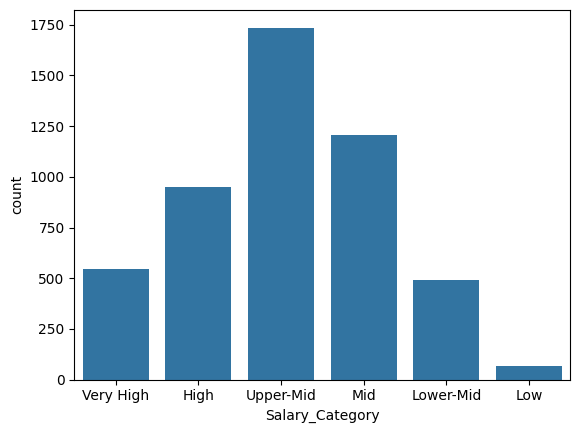

In [ ]:
min_salary = jobs['Salary_USD'].min()
max_salary = jobs['Salary_USD'].max()
med_salary = jobs['Salary_USD'].median()

print(f'Минимальная зарплата в выборке: {min_salary} $')
print(f'Максимальная зарплата в выборке: {max_salary} $')
print(f'Медианная зарплата в выборке: {med_salary} $')


sns.countplot(data=jobs, x='Salary_Category')

Давайте проверим, что нет ошибок в столбцах, связанных с заработной платой. Необходимо проверить:
1) Salary_Min <= Salary_Max
2) Salary_Min <= Salary_USD <= Salary_Max
3) Проверить, что категории зарплат соответствуют реальным интервалам Salary_USD

In [7]:
# Сверка категорий с фактическими интервалами
checks = jobs.groupby('Salary_Category')['Salary_USD'].agg(['min', 'max'])
print(checks)


                      min       max
Salary_Category                    
High             180042.0  249690.0
Low               27934.0   49877.0
Lower-Mid         50127.0   79957.0
Mid               80058.0  119988.0
Upper-Mid        120130.0  179971.0
Very High        250084.0  718357.0


# Проверка гипотез
В описании данной работы были сформированы несколько гипотез, которые надо проверить:
1) Уровень оплаты зависит от страны, в которой находится компания;
2) Более высокий требуемый уровень образования связан с более высокой заработной платой;
3) Python является наиболее востребованным языком программирования среди AI-вакансий;
4) Чем выше требуемый опыт, тем ниже риск автоматизации;

## Влияние страны на уровень оплаты
В качестве метрики, по которой будет проводиться сравнение, выберем полный доход. Он будет состоять из основной заплаты, годового бонуса и различных бенефитов, доступных на данной вакансии. Сравнивать просто по итоговой зарплате не имеет никакого смысла, так как каждая вакансия характеризуется требуемым уровнем опыта, масштабом компании и специальностью деятельности. Для этого выделим несколько когорт по следующему признаку: $$\text{Сегмент} = \text{AI_Specialization} \times \text{Experience_Level} \times \text{Company_Size}$$

Выделим крупнейшие когорты


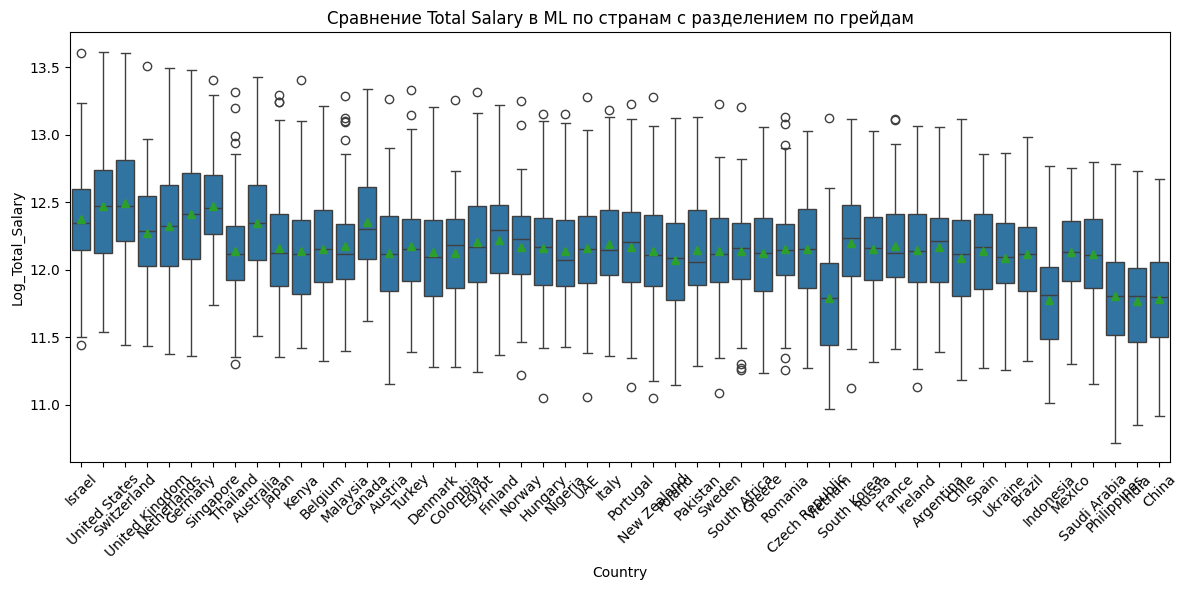

In [6]:
jobs['Total_Salary'] = jobs['Salary_USD'] * (1 + jobs['Bonus_%'] / 100) + jobs['Benefits_Value_USD']

jobs['Log_Total_Salary'] = np.log(jobs['Total_Salary'])

top_spec = jobs['AI_Specialization'].value_counts().index[0]
subset = jobs.query("AI_Specialization == @top_spec and Experience_Level == 'Mid'")


plt.figure(figsize=(12, 6))
sns.boxplot(
    data=subset,
    x=jobs['Country'],
    y=jobs['Log_Total_Salary'],
    showmeans=True
)
plt.xticks(rotation=45)
plt.title("Сравнение Total Salary в ML по странам с разделением по грейдам")
plt.tight_layout()
plt.show()

In [ ]:
# Находим все параметры модели, относящиеся к Country
country_params = [col for col in model.params.index if 'C(Country' in col]

# Проверяем гипотезу: все beta_Country == 0 одновременно
hypothesis = ' = '.join(country_params) + ' = 0'
wald_test = model.f_test(hypothesis)

print("\n--- Результаты общего теста на влияние страны ---")
print(f"F-statistic: {wald_test.fvalue:.4f}")
print(f"p-value:     {wald_test.pvalue:.4e}")

if wald_test.pvalue < 0.05:
    print("ВЫВОД: Страна оказывает статистически значимое влияние на уровень компенсации при равных квалификациях и ролях.")
else:
    print("ВЫВОД: Различия в зарплатах между странами объясняются различиями в грейдах, опыте и специализациях.")


--- Результаты общего теста на влияние страны ---
F-statistic: 50.3320
p-value:     0.0000e+00
ВЫВОД: Страна оказывает статистически значимое влияние на уровень компенсации при равных квалификациях и ролях.


# Более высокий требуемый уровень образования связан с более высокой заработной платой

Для проверки данной гипотезы нужно учесть, что Salary_USD - непрерывная метрика с смещенным распределением, а Education_Required - порядковая категориальная переменная, где уровни нельзя складывать, но можно выстроить четкое ранжирование (PhD $>$ Master's $>$ Bachelor's). Нюанс проверки данной гипотезы - ложная корреляция. Люди с PhD часто имеют больше лет опыта или работают на специфических ролях (например, Chief Data Scientist), которые сами по себе оплачиваются выше.

Какие методы были применены:


1. Ранговая корреляция Спирмена: алгоритм выстраивает все вакансии в очередь от самого низкого образования к самому высокому, и вторую очередь — от самой низкой зарплаты к самой высокой. Тест проверяет: если вакансия делает шаг вверх в «очереди образования», делает ли она шаг вверх в «очереди зарплат»? Если да, коэффициент $\rho$ будет положительным.
2. Многофакторная регрессия (OLS): модель создает виртуальную ситуацию: она сравнивает зарплаты специалиста с Бакалавриатом и специалиста с PhD, при условии, что у них абсолютно одинаковый опыт работы и одинаковая специализация.
3. Интерпретация: Если регрессия показывает, что коэффициент при PhD значим ($p < 0.05$) и положителен, гипотеза подтверждается в строгом смысле — рынок доплачивает именно за диплом, а не за сопутствующий ему опыт.



In [4]:
import scipy.stats as stats
import statsmodels.formula.api as smf

# 1. Задаем строгий порядок (адаптируйте под категории из датасета)
edu_order = {
    "Bachelor's": 0,
    "Master's": 1,
    "Postdoctoral": 1,
    'PhD': 4
}
jobs['Edu_Rank'] = jobs['Education_Required'].map(edu_order)

# 2. Ранговая корреляция Спирмена
rho, p_val_spearman = stats.spearmanr(jobs['Edu_Rank'], jobs['Salary_USD'])
print(f"Spearman rho: {rho:.3f}, p-value: {p_val_spearman:.4e}")

# 3. Контроль сопутствующих факторов через OLS
ols_edu = smf.ols(
    "np.log(Salary_USD) ~ C(Education_Required, Treatment(reference=\"Bachelor's\")) + Years_of_Experience + C(Experience_Level)",
    data=jobs
).fit(cov_type='HC3')
print(ols_edu.summary().tables[1])

Spearman rho: 0.011, p-value: 4.5285e-01
                                                                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                   11.1661      0.016    682.320      0.000      11.134      11.198
C(Education_Required, Treatment(reference="Bachelor's"))[T.Master's]         0.0076      0.011      0.681      0.496      -0.014       0.030
C(Education_Required, Treatment(reference="Bachelor's"))[T.PhD]             -0.0003      0.013     -0.025      0.980      -0.025       0.024
C(Education_Required, Treatment(reference="Bachelor's"))[T.Postdoctoral]     0.0174      0.020      0.874      0.382      -0.022       0.057
C(Experience_Level)[T.Executive]                                             1.5334      0.023     67.669      0.

## Python является наиболее востребованным языком программирования среди AI-вакансий

Любая вакансия требует владения определенным набором навыков, который позволит выполнять данную работу на высоком уровне.

Какие методы были применены:
1. Бинаризация: сначала текст превращается в набор независимых рубильников. Для каждого языка создается колонка: $1$, если язык есть в требованиях, и $0$, если нет. Поиск происходит при помощи регулярных выражений с границами слов
2. Сравнение долей (Критерий Мак-Немара): Допустим, мы нашли, что Python встречается в $85\%$ вакансий, а SQL — в $75\%$. Чтобы заявить, что Python статистически лидер, нужно доказать, что эта разница в $10\%$ не является случайным шумом нашей конкретной выборки. Стандартный Z-тест здесь не работает, потому что выборки зависимы (это одни и те же вакансии).
3. Интуиция теста: Критерий Мак-Немара отбрасывает вакансии, где нужны оба языка (они не помогают выявить победителя), и вакансии, где не нужен ни один. Он смотрит только на разногласия: сколько вакансий просят Python без SQL, и сколько — SQL без Python. Если первая группа статистически значимо больше, Python признается абсолютным лидером.

In [ ]:
import pandas as pd
import re
from statsmodels.stats.contingency_tables import mcnemar

# 1. Разделение строк и создание плоского списка навыков
# Разбиваем строку по запятой, разворачиваем списки в строки (explode) и удаляем лишние пробелы (strip)
skills_expanded = jobs['Skills_Required'].dropna().str.split(',').explode().str.strip()

# 2. Подсчет популярности навыков
total_vacancies = len(jobs)
skill_counts = skills_expanded.value_counts()
skill_share = (skill_counts / total_vacancies) * 100

print("Топ-10 самых востребованных навыков (%):")
print(skill_share.head(10))

# 3. Статистический тест для Топ-1 и Топ-2 навыков
# Динамически берем двух лидеров из получившегося списка
top1_skill = skill_share.index[0]
top2_skill = skill_share.index[1]

# Функция для точного поиска навыка как самостоятельного слова (чтобы 'C' не нашлось в 'C++')
def create_skill_flag(df, skill):
    # re.escape защищает спецсимволы (например, плюсы в C++)
    pattern = r'\b' + re.escape(skill) + r'\b'
    return df['Skills_Required'].str.contains(pattern, case=False, na=False).astype(int)

jobs[f'has_{top1_skill}'] = create_skill_flag(jobs, top1_skill)
jobs[f'has_{top2_skill}'] = create_skill_flag(jobs, top2_skill)

# Таблица сопряженности и тест Мак-Немара
contingency = pd.crosstab(jobs[f'has_{top1_skill}'], jobs[f'has_{top2_skill}'])
res = mcnemar(contingency, exact=False, correction=True)

print(f"\nСравнение лидера ('{top1_skill}') и ближайшего преследователя ('{top2_skill}') (McNemar test):")
print(f"p-value = {res.pvalue:.4e}")

Топ-10 самых востребованных навыков (%):
Skills_Required
Python           80.16
PyTorch          27.92
SQL              19.62
Research         17.36
AWS/GCP/Azure    16.92
AWS/GCP          15.04
Deep Learning    14.36
C++              13.78
Teaching         12.28
Docker           11.68
Name: count, dtype: float64

Сравнение лидера ('Python') и ближайшего преследователя ('PyTorch') (McNemar test):
p-value = 0.0000e+00


Данные результаты говорят нам о том, что Python - статистически значимый лидер: он требуется в 80% вакансиях против 20% у ближайшего языка SQL. Для аналитика это значит, что Python остаётся базовым навыком входа в AI/данные

## Чем выше требуемый опыт, тем ниже риск автоматизации

Обе переменные — непрерывные числа (годы опыта и проценты риска от $0$ до $100$). Мы ищем обратную (отрицательную) связь. Главный риск здесь заключается в том, что эта зависимость, скорее всего, нелинейна. Разница в риске автоматизации между $0$ и $2$ годами опыта может быть огромной, а между $10$ и $12$ годами — нулевой (Senior-специалисты одинаково защищены).

Какие методы были применены:
1. Односторонняя корреляция Спирмена: в отличие от классической корреляции Пирсона, которая ищет строгую прямую линию, Спирмен ищет любую монотонную зависимость (главное, чтобы график шел вниз, пусть даже криво или ступеньками). Мы задаем параметр alternative='less', указывая тесту искать именно отрицательный тренд.

2. Тест Краскела — Уоллиса по грейдам: часто на практике точные годы опыта (Years_of_Experience) заполнены с ошибками, а текстовые грейды (Experience_Level: Junior, Middle, Senior) более надежны. Краскел — Уоллис берет медианные значения риска автоматизации в каждой из этих групп и проверяет, есть ли между ними статистически значимая ступенька.

3. Интерпретация: Если $p < 0.05$, мы отвергаем случайность и делаем вывод, что накопление опыта действительно служит защитным барьером от автоматизации, снижая её вероятность.

Spearman rho (Experience vs Automation Risk): -0.004, p-value: 3.8162e-01
Kruskal-Wallis across levels: p-value = 9.3218e-01


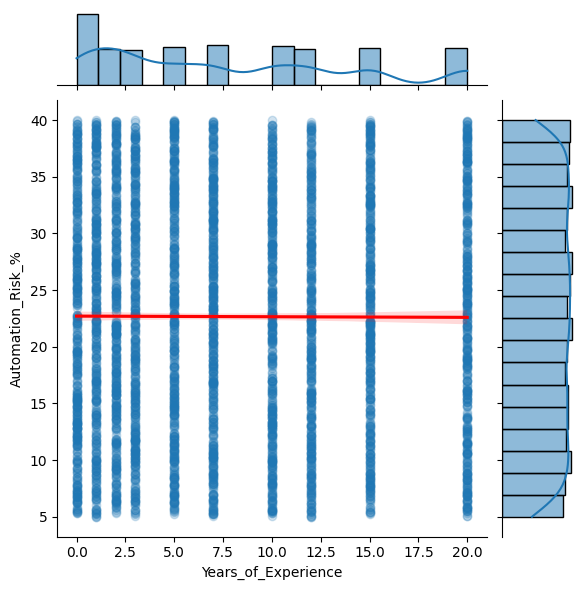

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Корреляция Спирмена (односторонний тест на отрицательную связь)
rho, p_val = stats.spearmanr(jobs['Years_of_Experience'], jobs['Automation_Risk_%'], alternative='less')
print(f"Spearman rho (Experience vs Automation Risk): {rho:.3f}, p-value: {p_val:.4e}")

# 2. Непараметрический тест различий по грейдам
exp_groups = [group['Automation_Risk_%'].values for _, group in jobs.groupby('Experience_Level')]
kw_stat, kw_pval = stats.kruskal(*exp_groups)
print(f"Kruskal-Wallis across levels: p-value = {kw_pval:.4e}")

# 3. Визуальная оценка связи
sns.jointplot(
    data=jobs,
    x='Years_of_Experience',
    y='Automation_Risk_%',
    kind='reg',
    scatter_kws={'alpha': 0.2},
    line_kws={'color': 'red'}
)
plt.show()

Как мы можем наблюдать по полученным данным, высокая должность и годы опыта не являются защитным барьером от автоматизации.

Теперь проверим, есть ли корреляция между AI_Specialization и Automation_Risk_%. Так как Automation_Risk_% — это числовая переменная, а AI_Specialization — категориальная, наша задача сводится к сравнению средних (или медиан) значений риска в нескольких независимых группах.

In [ ]:
import scipy.stats as stats
import pandas as pd

# Группируем значения риска по специализациям в список массивов
risk_by_spec = [
    group['Automation_Risk_%'].dropna().values
    for _, group in jobs.groupby('AI_Specialization')
]

# Запускаем тест
kw_stat, kw_pval = stats.kruskal(*risk_by_spec)

print(f"Kruskal-Wallis statistic: {kw_stat:.3f}")
print(f"p-value: {kw_pval:.4e}")

if kw_pval < 0.05:
    print("ВЫВОД: Риск автоматизации статистически значимо зависит от специализации (AI_Specialization).")
else:
    print("ВЫВОД: Различий в риске автоматизации между специализациями не обнаружено.")

Kruskal-Wallis statistic: 6.268
p-value: 5.0878e-01
ВЫВОД: Различий в риске автоматизации между специализациями не обнаружено.


/tmp/ipykernel_1524/309612271.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


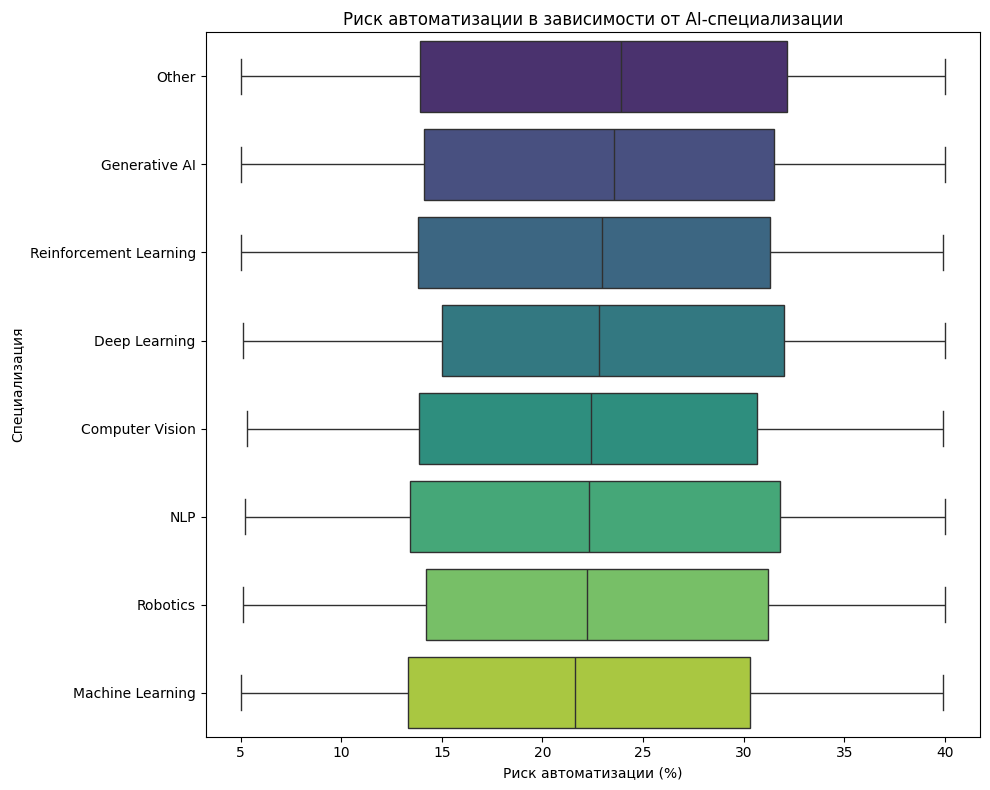

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Строим boxplot
sns.boxplot(
    data=jobs,
    x='Automation_Risk_%',
    y='AI_Specialization',
    order=jobs.groupby('AI_Specialization')['Automation_Risk_%'].median().sort_values(ascending=False).index, # Сортируем по убыванию риска
    palette='viridis'
)

plt.title('Риск автоматизации в зависимости от AI-специализации')
plt.xlabel('Риск автоматизации (%)')
plt.ylabel('Специализация')
plt.tight_layout()
plt.show()

Визуализация полностью подтверждает отсутствие статистически значимой связи между конкретной специализацией в ИИ и риском автоматизации. Boxplot для всех категорий выглядят практически одинаково. Медианы выстроены в одну вертикальную линию примерно на уровне 22–24%. Ни в одной из категорий нет аномальных значений.

Эти данные могут нам говорить о синтетической природе этих данных или о том, что на данный момент времени развитие ИИ находится в начальном этапе и не может пока что полностью заменить человека. ИИ может быть полезным инструментом для работника, который может облегчить его работу, тем самым освободив время для более важных проектов.